# GraphRAG vs single-agent belief store

Compare `eval_results_graphrag.csv` with the data used by
[final_single_agent_analysis.ipynb](final_single_agent_analysis.ipynb).
The main single-agent source is `eval_results_normalized.csv`; the original
notebook's supplemental source, `eval_results_with_store.csv`, is kept separate.
Run all cells from the repository root. No model calls or new evaluations are made.

**Reading order:** coverage and metric definitions → matched accuracy → calibration →
stability and extraction → prompt sensitivity → unmatched/supplemental results → diagnostics and findings.

**Comparison policy**
- Primary accuracy comparison: GraphRAG versus **With Store averaged over v15 and v16**,
  and **No Store averaged over v1 and v2**. Each prompt variant receives equal weight within
  each matched model–domain cell; then cells receive equal weight in the overall score.
  Both variants must be present. This summarizes performance across prompt variants, not an ensemble.
- Other metrics retain the explicit GraphRAG v1 / With Store v16 / No Store v1 comparison;
  Section 6 retains separate prompt-version results for interpretation.
  The CSV metadata pairs v16/v1 and v15/v2; the original notebook's version headings reverse these pairs.
  These baseline versions are inferred by `scripts/normalize_eval_csvs.py`, not independent execution metadata.
- Match comparison model label, domain, temperature, and run count. Average equally over matched model–domain
  cells, after computing each GraphRAG cell from its turns. Each metric uses its own complete-case support.
  Missing values are never filled with zero. Preserve separate prompt-version results as supporting detail.
- Both Qwen results use no-thinking mode and are labeled **qwen3:4b (no-thinking)** throughout
  the charts and summaries.
- This is a descriptive comparison of separate experiments. Single-agent summaries lack turn-level records,
  seeds, and question/history settings. Exact question pairing and causal attribution are unavailable.
  GraphRAG uses supplied targets and snapshot history, so results do not measure end-to-end target discovery.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from evaluation.eval_metrics import (
    brier_score, log_loss_score, expected_calibration_error, macro_calibration_error,
)

ROOT = Path.cwd()
GRAPH_PATH = ROOT / "eval_results_graphrag.csv"
SINGLE_PATH = ROOT / "eval_results_normalized.csv"
SUPPLEMENT_PATH = ROOT / "eval_results_with_store.csv"
graph = pd.read_csv(GRAPH_PATH)
single = pd.read_csv(SINGLE_PATH)
supplement = pd.read_csv(SUPPLEMENT_PATH)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

provenance = pd.DataFrame([
    {"file": p.name, "rows": len(df), "sha256": hashlib.sha256(p.read_bytes()).hexdigest()}
    for p, df in [(GRAPH_PATH, graph), (SINGLE_PATH, single), (SUPPLEMENT_PATH, supplement)]
])
display(provenance)

,file,rows,sha256
0,eval_results_graphrag.csv,8000,2938095d97ae14d8a15db27897c90c63033de78b92aeea...
1,eval_results_normalized.csv,6602,502e396420948ea7b3273f7c9d8f6a4f08527bc26b673f...
2,eval_results_with_store.csv,2464,d59a70f88104a84731e550fd927e4586726ec12385c521...


## 1. Coverage and validation

Check turn uniqueness, run completeness, missing probabilities, and experimental settings before aggregation.
The manifest, when present, supplies expected model/domain/run coverage.
The coverage tables use consistent model labels across both result sources.

In [2]:
for column in ["hit", "end_to_end_correct", "think", "response_cache"]:
    parsed = graph[column].astype(str).str.strip().str.lower().map({"true": True, "false": False})
    assert parsed.notna().all(), f"Invalid boolean in {column}"
    graph[column] = parsed.astype(bool)
for column in ["decision_prob", "mean_answer_prob", "min_answer_prob"]:
    graph[column] = pd.to_numeric(graph[column], errors="raise")
    assert graph[column].dropna().between(0, 1).all(), column
single["Value"] = pd.to_numeric(single["Value"], errors="raise")
assert set(single.Condition) == {"With_Store", "No_Store"}
assert not graph.duplicated(["model", "domain", "run", "turn"]).any(), "Duplicate GraphRAG turns"
assert (graph.hit == graph.end_to_end_correct).all()
assert (graph.hit == graph.answer.eq(graph.correct)).all(), "Hit/answer disagreement"
settings = ["condition", "temperature", "think", "baseline_prompt_version", "history_mode",
            "response_cache", "question_policy", "scenario_seed", "retriever_version", "target_mode", "ollama_options"]
assert (graph[settings].nunique(dropna=False) == 1).all(), "Split mixed GraphRAG configurations first"
assert graph.baseline_prompt_version.eq("v1").all(), "Revisit the selected prompt cohort"
display(pd.DataFrame({"setting": settings, "GraphRAG value": [graph[c].iloc[0] for c in settings]}))
display(single.groupby(["Condition", "Eval_Prompt_Ver", "Baseline_Prompt_Ver"])
        .agg(rows=("Value", "size"), missing_values=("Value", lambda s: s.isna().sum())))

run_coverage = graph.groupby(["model", "domain", "run"]).turn.agg(["size", "nunique"])
assert (run_coverage["size"] == run_coverage["nunique"]).all()
manifest_path = ROOT / "eval_results_graphrag.manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    cfg = manifest["config"]
    expected = {(m, d, r) for m in cfg["models"] for d in cfg["domains"]
                for r in range(1, cfg["runs_per_config"] + 1)}
    assert set(run_coverage.index) == expected, "Missing/unexpected model-domain-run combinations"
    planned_turns = {(r["domain"], r["run"]): len(r["turns"]) for r in manifest["runs"]}
    assert all(row["size"] == planned_turns[(d, r)] for (m, d, r), row in run_coverage.iterrows())
assert run_coverage.groupby(level=["model", "domain"])["size"].nunique().eq(1).all()
QWEN_LABEL = "qwen3:4b (no-thinking)"
MODEL_ALIASES = {"qwen3:4b": QWEN_LABEL, "hoangquan456/qwen3-nothink:4b": QWEN_LABEL}
graph["Source_Model"] = graph.model
graph["model"] = graph.model.replace(MODEL_ALIASES)
comparison_models = sorted(set(graph.model) & set(single.Model.replace(MODEL_ALIASES)))
display(graph.groupby("model").agg(
    turns=("hit", "size"), domains=("domain", "nunique"), runs_per_domain=("run", "nunique"),
    accuracy=("hit", "mean"), missing_answers=("answer", lambda s: s.isna().sum()),
    missing_decision_probs=("decision_prob", lambda s: s.isna().sum()),
))


,setting,GraphRAG value
0,condition,GRAPH RETRIEVAL (SUPPLIED TARGETS)
1,temperature,0.0000
2,think,False
3,baseline_prompt_version,v1
4,history_mode,snapshot
5,response_cache,False
6,question_policy,sampled_paraphrases
7,scenario_seed,0
8,retriever_version,domain-dependency-v2
9,target_mode,supplied


rows  missing_values
Condition  Eval_Prompt_Ver Baseline_Prompt_Ver                      
No_Store   v15             v2                   1356               0
           v16             v1                   1584               0
With_Store v15             v2                   1956               0
           v16             v1                   1706               0

,turns,domains,runs_per_domain,accuracy,missing_answers,missing_decision_probs
model,,,,,,
gemma3:1b,1600,16,10,0.2706,624,310
gemma4:e2b,1600,16,10,0.7544,68,80
llama3.2:1b,1600,16,10,0.2637,303,456
ministral-3:3b,1600,16,10,0.7019,58,63
qwen3:4b (no-thinking),1600,16,10,0.3850,950,934


## 2. Metric definitions and GraphRAG aggregation

Use the repository's calibration functions directly (`evaluation/eval_metrics.py`) and mirror
`evaluation/eval_orchestrator.py` for the remaining shared metrics.

| Metric | Definition / interpretation |
|---|---|
| Accuracy ↑ | Mean run accuracy; failed answer extractions count as incorrect. |
| Brier, log loss, ECE, MacroCE ↓ | Binary correctness versus answer confidence; ECE uses **3 equal-width bins**. Compute over pooled valid-confidence turns within each model/domain, then macro-average cells. |
| Confidence | `decision_prob`, falling back to `mean_answer_prob` when missing. These are token-derived confidence proxies, not normalized probabilities over answer choices. No qualitative HIGH/LOW conversion. |
| AFR ↓ | Per turn index, fraction of nonmissing answers differing from the modal answer across runs; average over turn indices having an answer. Not adjacent-turn flips. |
| Determinism ↑ | Fraction of turn indices with one unique nonmissing answer; all-missing indices count as inconsistent. Interpret alongside EFR. |
| EFR ↓ | Fraction of turns without an extracted answer. |
| Raw-score variance / SD | Sample variance/SD of number correct per run, in count²/count units. Not accuracy variance. |
| PTC variance | Sample variance of per-turn-index accuracy across runs. Measures variation in turn difficulty, not a standard error. |
| TPCA | Mean response whitespace-word count for correct/incorrect turns; these are words, not tokens. No directional ranking. |
| Extraction-method share | Share among turns with a recorded extraction method, not among all attempts. |

GraphRAG runs use sampled paraphrases, so AFR and determinism reflect both paraphrase sensitivity and
generation variability. No significance tests or paired confidence intervals are inferred from historical aggregates.
The legacy confidence fallback uses Python `or`; there are no zero decision probabilities in this input,
so missing-only fallback produces identical results. Undefined word-count means stay missing, even though
the legacy exporter uses zero when there are no correct/incorrect turns.

In [3]:
graph["p_calibration"] = graph.decision_prob.fillna(graph.mean_answer_prob)
assert not graph.decision_prob.eq(0).any(), "Check compatibility with legacy zero-probability fallback"
graph["response_words"] = graph.response.fillna("").str.split().str.len()

def summarize_graph(group):
    per_run = group.groupby("run").hit.agg(["sum", "mean", "size"])
    assert per_run["size"].nunique() == 1, "Unequal run lengths"
    answers = group.groupby("turn").answer
    flip_rates = [1 - s.value_counts().max() / s.notna().sum()
                  for _, s in answers if s.notna().any()]
    valid = group.dropna(subset=["p_calibration"])
    predictions = list(zip(valid.p_calibration, valid.hit.astype(int)))
    methods = group.extraction_method.dropna()
    result = {
        "Average_Accuracy": per_run["mean"].mean(),
        "Variance_Raw_Score": per_run["sum"].var(ddof=1),
        "StdDev_Raw_Score": per_run["sum"].std(ddof=1),
        "AFR_Answer_Flip_Rate": np.mean(flip_rates) if flip_rates else np.nan,
        "DS_Determinism_Score": answers.nunique().eq(1).mean(),
        "EFR_Extraction_Failure_Rate": group.answer.isna().mean(),
        "PTC_Variance_PerTurn_Consistency": group.groupby("turn").hit.mean().var(ddof=1),
        "TPCA_Words_Correct": group.loc[group.hit, "response_words"].mean(),
        "TPCA_Words_Wrong": group.loc[~group.hit, "response_words"].mean(),
        "EMD_bracketed_exact": methods.eq("bracketed_exact").mean(),
        "Summary_Metric_Brier_Score": brier_score(predictions) if predictions else np.nan,
        "Summary_Metric_Log_Loss": log_loss_score(predictions) if predictions else np.nan,
        "Summary_Metric_ECE": expected_calibration_error(predictions, n_bins=3) if predictions else np.nan,
        "Summary_Metric_MacroCE": macro_calibration_error(predictions) if predictions else np.nan,
    }
    return result

graph_records = []
for (model, domain), group in graph.groupby(["model", "domain"]):
    graph_records.append({"Model": model, "Domain": domain, "Temp": group.temperature.iloc[0],
                          "Runs": group.run.nunique(), **summarize_graph(group)})
graph_wide = pd.DataFrame(graph_records)
KEYS = ["Model", "Domain", "Temp", "Runs"]
graph_long = graph_wide.melt(id_vars=KEYS, var_name="Metric", value_name="Value")
graph_long["System"] = "GraphRAG (v1)"

# EMD metric names explicitly identify the originating condition.
# The historical exporter put both conditions' EMD values in the With_Store value column.
single_work = single.copy()
single_work["Source_Model"] = single_work.Model
single_work["Model"] = single_work.Model.replace(MODEL_ALIASES)
emd_condition = single_work.Summary_Metric.str.extract(r"^EMD_(WithStore|NoStore)_", expand=False)
emd_mask = emd_condition.notna()
emd_repaired = int((single_work.loc[emd_mask, "Condition"] !=
                    emd_condition[emd_mask].map({"WithStore": "With_Store", "NoStore": "No_Store"})).sum())
single_work.loc[emd_mask, "Condition"] = emd_condition[emd_mask].map(
    {"WithStore": "With_Store", "NoStore": "No_Store"})
# Evidence and fidelity are collected only for condition_idx == 0 in the evaluator.
# Timing is also exported once in the store column, but measures the entire parallel batch.
store_only = (single_work.Summary_Metric.str.startswith("Average_Evidence_") |
              single_work.Summary_Metric.isin(["Average_BCR_BeliefCoverage",
                  "Average_SBIR_SpuriousInjection", "WCT_WallClock_PerTurn_Seconds"]))
auxiliary_repaired = int((store_only & single_work.Condition.ne("With_Store")).sum())
label_audit = single_work.loc[store_only].groupby(["Summary_Metric", "Condition"]).size().unstack(fill_value=0)
single_work.loc[store_only, "Condition"] = "With_Store"
single_work["Metric"] = single_work.Summary_Metric.str.replace(r"^EMD_(WithStore|NoStore)_", "EMD_", regex=True)
single_work["System"] = np.where(
    single_work.Condition.eq("With_Store"),
    "With Store (" + single_work.Eval_Prompt_Ver + ")",
    "No Store (" + single_work.Baseline_Prompt_Ver + ")",
)
assert not single_work.duplicated(KEYS + ["System", "Metric"]).any(), "Resolve repeated experiments before averaging"
combined = pd.concat([graph_long, single_work[KEYS + ["Metric", "Value", "System"]]], ignore_index=True)
SYSTEMS = ["GraphRAG (v1)", "With Store (v16)", "No Store (v1)"]
COLORS = ["#7c3aed", "#0284c7", "#ea580c"]
print(f"Repaired {emd_repaired} EMD and {auxiliary_repaired} auxiliary condition labels in memory; source files unchanged.")
display(Markdown("**Original auxiliary row labels (before correction):**"))
display(label_audit)

metric_names = {
    "Average_Accuracy": "Accuracy ↑",
    "Summary_Metric_Brier_Score": "Brier ↓",
    "Summary_Metric_Log_Loss": "Log loss ↓",
    "Summary_Metric_ECE": "ECE ↓",
    "Summary_Metric_MacroCE": "MacroCE ↓",
    "EFR_Extraction_Failure_Rate": "Extraction failure ↓",
    "AFR_Answer_Flip_Rate": "Answer flip rate ↓",
    "DS_Determinism_Score": "Determinism ↑",
    "Variance_Raw_Score": "Raw-score variance",
    "StdDev_Raw_Score": "Raw-score SD",
    "PTC_Variance_PerTurn_Consistency": "Per-turn accuracy variance",
    "TPCA_Words_Correct": "Words / correct response",
    "TPCA_Words_Wrong": "Words / incorrect response",
    "EMD_bracketed_exact": "Bracketed exact / recorded methods",
}

def matched_table(metric, systems=SYSTEMS):
    subset = combined[combined.Metric.eq(metric) & combined.Model.isin(comparison_models)]
    wide = subset.pivot(index=KEYS, columns="System", values="Value").reindex(columns=systems)
    return wide.dropna(subset=systems)

def bar_chart(table, title, ylabel, ylim=None):
    ax = table.plot.bar(figsize=(max(8, len(table) * 1.6), 4.5), color=COLORS + ["#059669", "#d97706"], width=0.8)
    ax.set(title=title, ylabel=ylabel, xlabel="")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()
    plt.close(ax.figure)

ALL_SYSTEMS = SYSTEMS + ["With Store (v15)", "No Store (v2)"]
ACCURACY_SYSTEMS = ["GraphRAG (v1)", "With Store (mean v15/v16)", "No Store (mean v1/v2)"]

def aggregate_accuracy(variant_table):
    # Require both variants per condition; never silently average a single available variant.
    complete = variant_table.reindex(columns=ALL_SYSTEMS).dropna()
    return pd.DataFrame({
        ACCURACY_SYSTEMS[0]: complete["GraphRAG (v1)"],
        ACCURACY_SYSTEMS[1]: (complete["With Store (v15)"] + complete["With Store (v16)"]) / 2,
        ACCURACY_SYSTEMS[2]: (complete["No Store (v1)"] + complete["No Store (v2)"]) / 2,
    })

accuracy_variants = matched_table("Average_Accuracy", ALL_SYSTEMS)
accuracy = aggregate_accuracy(accuracy_variants)
assert not accuracy.empty, "No complete accuracy support across both prompt variants"


Repaired 178 EMD and 456 auxiliary condition labels in memory; source files unchanged.


**Original auxiliary row labels (before correction):**

Condition,No_Store,With_Store
Summary_Metric,,
Average_BCR_BeliefCoverage,57,127
Average_Evidence_Canonical_Keys,57,127
Average_Evidence_Cited_Keys,57,127
Average_Evidence_F1,57,127
Average_Evidence_Precision,57,127
Average_Evidence_Recall,57,127
Average_SBIR_SpuriousInjection,57,127
WCT_WallClock_PerTurn_Seconds,57,127


System,GraphRAG (v1),No Store (v1),No Store (v2),With Store (v15),With Store (v16),GraphRAG comparison
Metric,,,,,,
AFR_Answer_Flip_Rate,80,92,92,92,92,Available (see definition)
Average_Accuracy,80,92,92,92,92,Available (see definition)
Average_BCR_BeliefCoverage,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_Evidence_Canonical_Keys,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_Evidence_Cited_Keys,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_Evidence_F1,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_Evidence_Precision,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_Evidence_Recall,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...
Average_SBIR_SpuriousInjection,0,0,0,92,92,Unavailable: no canonical evidence/fidelity la...


**Primary accuracy comparison: equal-weight prompt averages on shared support.**

,Aggregated accuracy,Accuracy (%),Matched model–domain cells,Prompt variants per cell
GraphRAG (v1),0.4751,47.5125,80,1
With Store (mean v15/v16),0.7142,71.4250,80,2
No Store (mean v1/v2),0.4646,46.4563,80,2


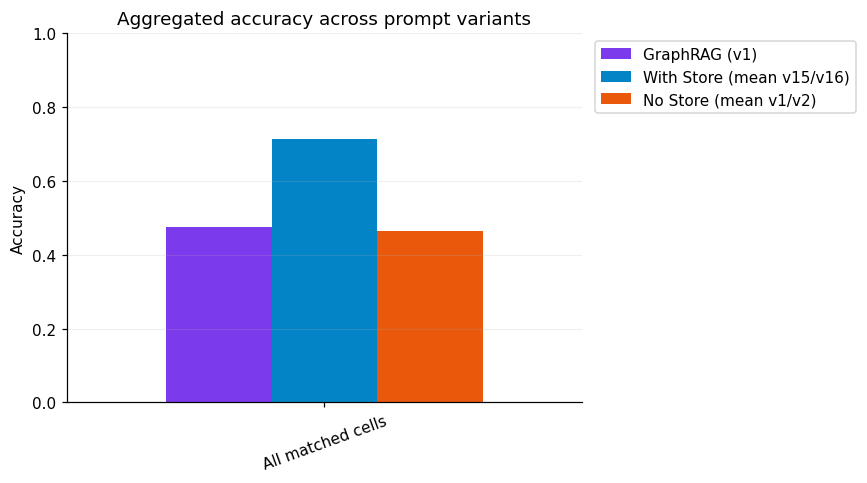

**Other metrics by the stated prompt versions (not aggregated across prompts); each row uses shared support.**

,Matched cells,GraphRAG (v1),With Store (v16),No Store (v1)
Metric,,,,
Brier ↓,76,0.3034,0.2327,0.3294
Log loss ↓,76,1.7130,1.5586,2.4720
ECE ↓,76,0.3248,0.2439,0.3477
MacroCE ↓,76,0.4479,0.3506,0.4662
Extraction failure ↓,80,0.2504,0.0917,0.2700
Answer flip rate ↓,80,0.0834,0.0265,0.1134
Determinism ↑,80,0.6275,0.8700,0.5125
Raw-score variance,80,0.6446,0.2538,0.7253
Raw-score SD,80,0.7477,0.3557,0.7460


System,GraphRAG (v1),No Store (v1),With Store (v16)
Metric,,,
Accuracy ↑,80,80,80
Answer flip rate ↓,80,80,80
Bracketed exact / recorded methods,80,80,74
Brier ↓,80,76,80
Determinism ↑,80,80,80
ECE ↓,80,76,80
Extraction failure ↓,80,80,80
Log loss ↓,80,76,80
MacroCE ↓,80,76,80


In [4]:
# Availability includes every metric in the reference source, including non-comparable ones.
availability = combined.groupby(["Metric", "System"]).Value.count().unstack().fillna(0).astype(int)
availability["GraphRAG comparison"] = [
    "Available (see definition)" if m in metric_names else
    "Unavailable: no elapsed time" if m.startswith("WCT_") else
    "Unavailable: no canonical evidence/fidelity labels"
    for m in availability.index
]
display(availability)

display(Markdown("**Primary accuracy comparison: equal-weight prompt averages on shared support.**"))
accuracy_scorecard = accuracy.mean().rename("Aggregated accuracy").to_frame()
accuracy_scorecard["Accuracy (%)"] = 100 * accuracy_scorecard["Aggregated accuracy"]
accuracy_scorecard["Matched model–domain cells"] = len(accuracy)
accuracy_scorecard["Prompt variants per cell"] = [1, 2, 2]
display(accuracy_scorecard)
bar_chart(accuracy.mean().to_frame("All matched cells").T,
          "Aggregated accuracy across prompt variants", "Accuracy", (0, 1))

scorecard_rows = []
for metric, label in metric_names.items():
    if metric == "Average_Accuracy":
        continue
    table = matched_table(metric)
    scorecard_rows.append({"Metric": label, "Matched cells": len(table), **table.mean().to_dict()})
scorecard = pd.DataFrame(scorecard_rows).set_index("Metric")
display(Markdown("**Other metrics by the stated prompt versions (not aggregated across prompts); each row uses shared support.**"))
display(scorecard)

coverage_rows = []
for metric in metric_names:
    for system in SYSTEMS:
        source = combined[combined.Model.isin(comparison_models) & combined.Metric.eq(metric) & combined.System.eq(system)]
        graph_keys = graph_wide[graph_wide.Model.isin(comparison_models)][KEYS]
        aligned = graph_keys.merge(source[KEYS + ["Value"]], on=KEYS, how="left", validate="one_to_one")
        coverage_rows.append({"Metric": metric_names[metric], "System": system,
                              "GraphRAG support cells": len(aligned),
                              "Available values on support": aligned.Value.notna().sum()})
display(pd.DataFrame(coverage_rows).pivot(index="Metric", columns="System", values="Available values on support"))

## 3. Aggregated accuracy, scenarios, and paired cell deltas

For each shared model–domain cell, compute:

- **With Store accuracy = (v15 accuracy + v16 accuracy) / 2**.
- **No Store accuracy = (v1 accuracy + v2 accuracy) / 2**.
- GraphRAG contributes its single available v1 accuracy once.

Then average equally over those cells for the overall, model, scenario, and domain-family views.
Both variants are required for each single-agent condition. The three systems use the same complete
support; prompt variants do not create extra model–domain observations. All source summaries have
10 runs, so the equal variant weighting also gives equal weight to their evaluation runs within each cell.
This is a mean of prompt-specific accuracy scores, not combined predictions or best-prompt selection.
The supplemental `v16_one_shot` experiment is not one of these two main-source variants.

Accuracy is on a 0–1 scale; differences are in **percentage points (pp)**.
Scenario suffixes include `absurd`, grounding, belief maintenance, and temporal absurdity.

All five models are included; both Qwen results are labeled `qwen3:4b (no-thinking)`.


,GraphRAG (v1),With Store (mean v15/v16),No Store (mean v1/v2)
Model,,,
gemma3:1b,0.2706,0.5613,0.3697
gemma4:e2b,0.7544,0.8397,0.5528
llama3.2:1b,0.2637,0.3884,0.1747
ministral-3:3b,0.7019,0.8850,0.6019
qwen3:4b (no-thinking),0.3850,0.8969,0.6238


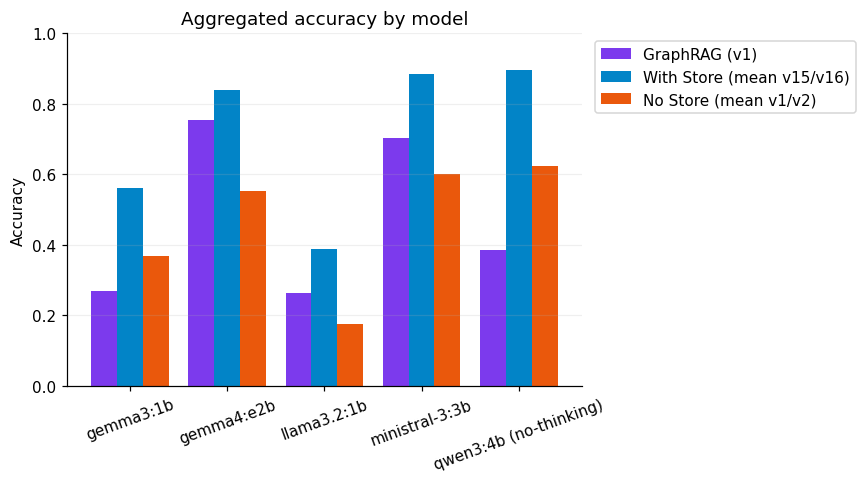

,GraphRAG (v1),With Store (mean v15/v16),No Store (mean v1/v2)
Scenario,,,
absurd,0.4470,0.8107,0.4497
absurd_temporal,0.4095,0.7330,0.3967
belief_maintenance,0.6405,0.8553,0.6075
grounding,0.4035,0.4580,0.4043


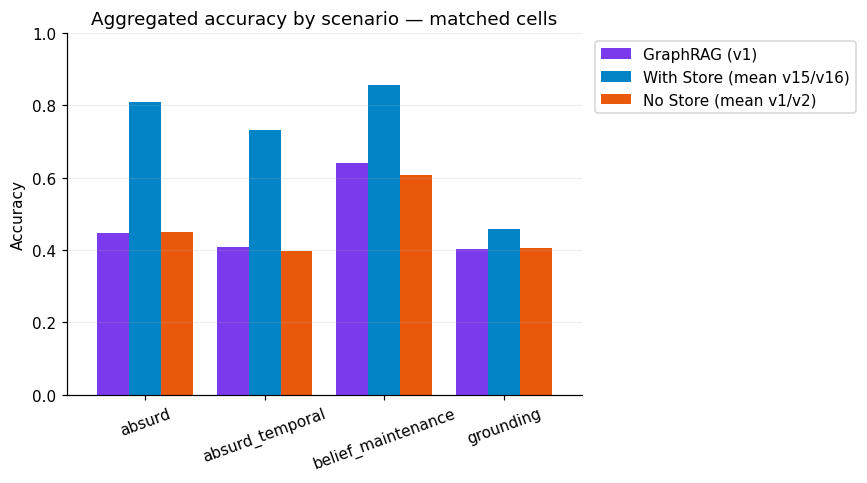

,GraphRAG (v1),With Store (mean v15/v16),No Store (mean v1/v2)
Family,,,
alien_clinic,0.3715,0.6715,0.3940
crime_scene,0.5005,0.7278,0.4720
loan,0.4390,0.7070,0.4293
thorncrester,0.5895,0.7508,0.5630


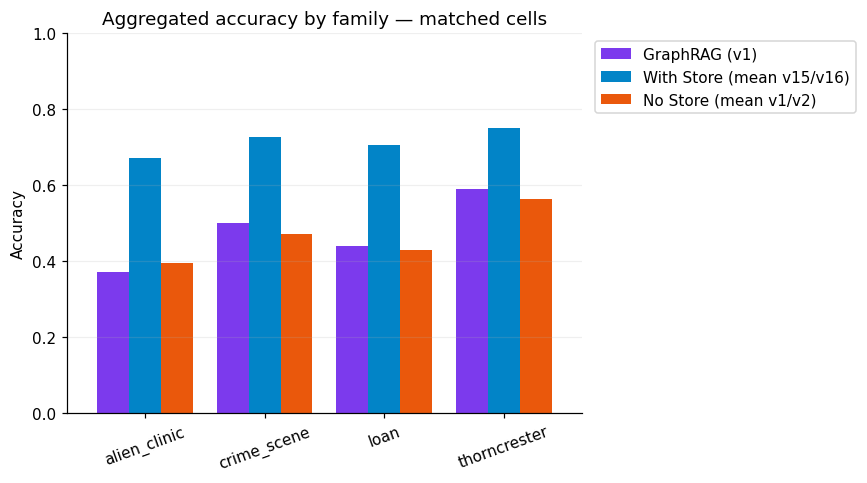

GraphRAG − With Store (mean v15/v16) (pp)           \
                                                            mean   median   
Model                                                                       
gemma3:1b                                               -29.0625 -36.0000   
gemma4:e2b                                               -8.5312  -4.2500   
llama3.2:1b                                             -12.4688 -12.7500   
ministral-3:3b                                          -18.3125 -14.0000   
qwen3:4b (no-thinking)                                  -51.1875 -50.2500   

                                          \
                            min      max   
Model                                      
gemma3:1b              -65.0000  24.5000   
gemma4:e2b             -37.5000  31.5000   
llama3.2:1b            -27.5000   6.5000   
ministral-3:3b         -52.0000  12.0000   
qwen3:4b (no-thinking) -97.0000 -18.0000   

                       GraphRAG − No Store (mean v1/v2) (pp)           \
                                                        mean   median   
Model                                                                   
gemma3:1b                                            -9.9062  -8.7500   
gemma4:e2b                                           20.1562  18.5000   
llama3.2:1b                                           8.9062   2.5000   
ministral-3:3b                                       10.0000   9.7500   
qwen3:4b (no-thinking)                              -23.8750 -26.0000   

                                         
                            min     max  
Model                                    
gemma3:1b              -33.5000 13.5000  
gemma4:e2b              -9.5000 48.0000  
llama3.2:1b            -14.0000 37.5000  
ministral-3:3b         -14.0000 28.0000  
qwen3:4b (no-thinking) -46.5000  0.5000

,Comparator,cells,GraphRAG wins,ties (≤0.01 pp),GraphRAG losses,mean delta (pp)
0,With Store (mean v15/v16),80,13,2,65,-23.9125
1,No Store (mean v1/v2),80,43,3,34,1.0563


**Largest gaps against With Store mean v15/v16 (both directions):**

,Model,Domain,Temp,Runs,GraphRAG (v1),With Store (mean v15/v16),No Store (mean v1/v2),Scenario,Family,GraphRAG − With Store (mean v15/v16) (pp),GraphRAG − No Store (mean v1/v2) (pp)
73,qwen3:4b (no-thinking),loan_absurd_temporal,0.0000,10,0.0300,1.0000,0.3800,absurd_temporal,loan,-97.0000,-35.0000
72,qwen3:4b (no-thinking),loan_absurd,0.0000,10,0.0700,1.0000,0.3750,absurd,loan,-93.0000,-30.5000
76,qwen3:4b (no-thinking),thorncrester_absurd,0.0000,10,0.2300,0.9850,0.5200,absurd,thorncrester,-75.5000,-29.0000
64,qwen3:4b (no-thinking),alien_clinic_absurd,0.0000,10,0.2500,0.9700,0.4350,absurd,alien_clinic,-72.0000,-18.5000
4,gemma3:1b,crime_scene_absurd,0.0000,10,0.1200,0.7700,0.4550,absurd,crime_scene,-65.0000,-33.5000
24,gemma4:e2b,loan_absurd,0.0000,10,0.8800,0.5650,0.9750,absurd,loan,31.5000,-9.5000
11,gemma3:1b,loan_grounding,0.0000,10,0.3600,0.1150,0.3100,grounding,loan,24.5000,5.0000
7,gemma3:1b,crime_scene_grounding,0.0000,10,0.1700,0.0350,0.3450,grounding,crime_scene,13.5000,-17.5000
63,ministral-3:3b,thorncrester_grounding,0.0000,10,0.9000,0.7800,0.6950,grounding,thorncrester,12.0000,20.5000
59,ministral-3:3b,loan_grounding,0.0000,10,0.7800,0.6900,0.5350,grounding,loan,9.0000,24.5000


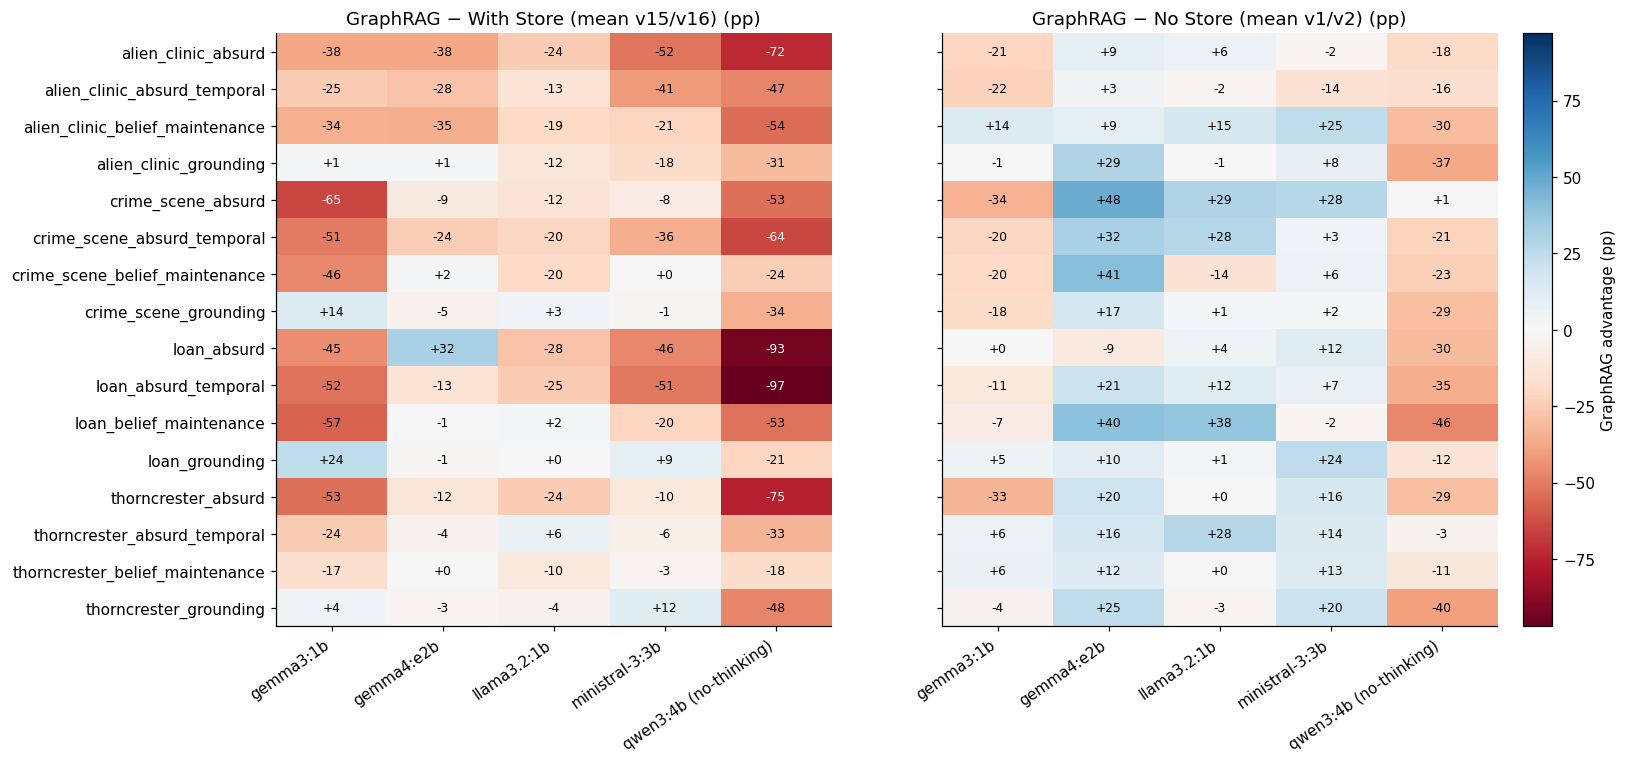

In [5]:
SCENARIOS = ["absurd_temporal_noise", "belief_maintenance", "absurd_temporal", "grounding", "absurd", "hard"]
def scenario_name(domain):
    return next((s for s in SCENARIOS if domain.endswith("_" + s)), "unknown")

acc = accuracy.reset_index()
acc["Scenario"] = acc.Domain.map(scenario_name)
acc["Family"] = [d.removesuffix("_" + s) for d, s in zip(acc.Domain, acc.Scenario)]
display(accuracy.groupby(level="Model").mean())
bar_chart(accuracy.groupby(level="Model").mean(), "Aggregated accuracy by model", "Accuracy", (0, 1))
for dimension in ["Scenario", "Family"]:
    table = acc.groupby(dimension)[ACCURACY_SYSTEMS].mean()
    display(table)
    bar_chart(table, f"Aggregated accuracy by {dimension.lower()} — matched cells", "Accuracy", (0, 1))

deltas = acc.copy()
for baseline in ACCURACY_SYSTEMS[1:]:
    deltas[f"GraphRAG − {baseline} (pp)"] = 100 * (deltas[ACCURACY_SYSTEMS[0]] - deltas[baseline])
delta_columns = [c for c in deltas if c.endswith("(pp)")]
display(deltas.groupby("Model")[delta_columns].agg(["mean", "median", "min", "max"]))
outcomes = []
# Legacy accuracy values are rounded to four decimals; use that resolution for ties.
for baseline, col in zip(ACCURACY_SYSTEMS[1:], delta_columns):
    values = deltas[col]
    outcomes.append({"Comparator": baseline, "cells": len(values),
                     "GraphRAG wins": (values > 0.01).sum(), "ties (≤0.01 pp)": (values.abs() <= 0.01).sum(),
                     "GraphRAG losses": (values < -0.01).sum(), "mean delta (pp)": values.mean()})
display(pd.DataFrame(outcomes))
display(Markdown("**Largest gaps against With Store mean v15/v16 (both directions):**"))
display(pd.concat([deltas.nsmallest(5, delta_columns[0]), deltas.nlargest(5, delta_columns[0])]))

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
limit = max(1, deltas[delta_columns].abs().to_numpy().max())
for ax, column in zip(axes, delta_columns):
    heat = deltas.pivot(index="Domain", columns="Model", values=column)
    im = ax.imshow(heat, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(heat.index)), heat.index)
    ax.set_title(column)
    for (i, j), value in np.ndenumerate(heat.to_numpy()):
        ax.text(j, i, f"{value:+.0f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > limit * 0.65 else "black")
fig.colorbar(im, ax=axes, label="GraphRAG advantage (pp)", fraction=0.025, pad=0.02)
plt.show()
plt.close(fig)

## 4. Calibration and confidence coverage

This section retains the explicit v16/v1 single-agent cohort shown in the column labels;
only the primary accuracy comparison is averaged over prompt variants.
Lower Brier, log loss, ECE, and MacroCE are better. Each metric's matched-cell count appears in the
scorecard. Missing confidence turns are excluded from calibration, **not** from accuracy or EFR.
Historical summaries do not contain confidence denominators, so their selection bias cannot be reconstructed.
Reliability diagrams below are GraphRAG-only and pool turns within each model; they are diagnostics,
not the macro-averaged matched scorecard. Token confidence should not be treated as a calibrated belief probability.

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.3945,0.4594,0.5791
gemma4:e2b,0.2087,0.1700,0.1936
llama3.2:1b,0.4688,0.3106,0.3868
ministral-3:3b,0.3565,0.1083,0.2622
qwen3:4b (no-thinking),0.1297,0.1349,0.2398


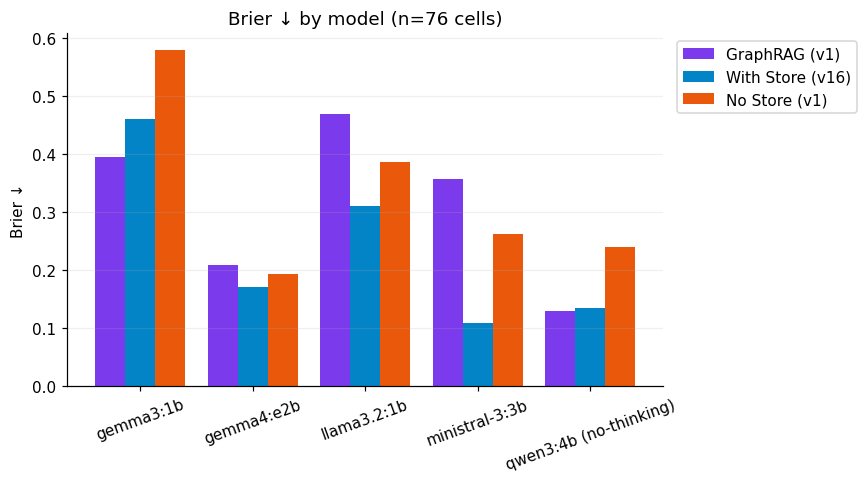

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,1.4388,2.6187,3.8626
gemma4:e2b,2.6022,1.8831,2.5216
llama3.2:1b,1.6724,1.0981,1.2851
ministral-3:3b,1.4256,0.4863,1.3584
qwen3:4b (no-thinking),1.4158,1.5916,3.0356


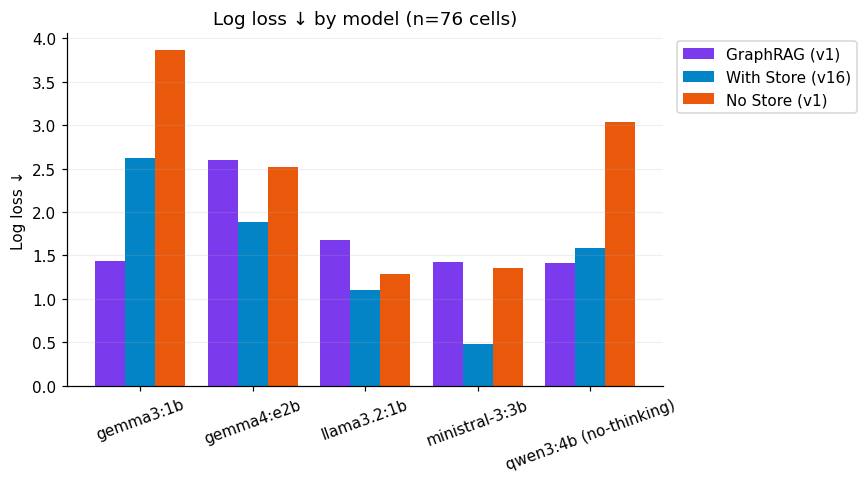

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.4142,0.4783,0.5993
gemma4:e2b,0.2111,0.1730,0.1897
llama3.2:1b,0.4998,0.3423,0.4918
ministral-3:3b,0.3971,0.1158,0.2566
qwen3:4b (no-thinking),0.1458,0.1350,0.2370


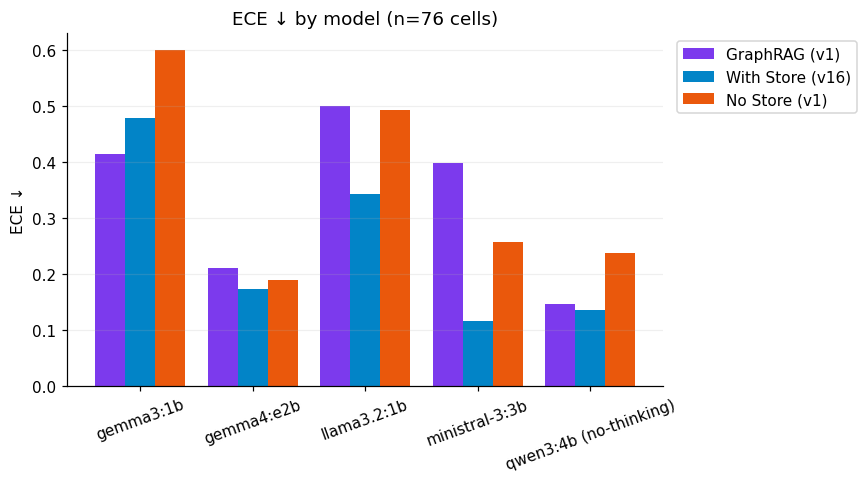

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.4395,0.4990,0.4909
gemma4:e2b,0.4660,0.2450,0.4295
llama3.2:1b,0.5208,0.4287,0.5381
ministral-3:3b,0.5343,0.2890,0.4579
qwen3:4b (no-thinking),0.2969,0.3111,0.4325


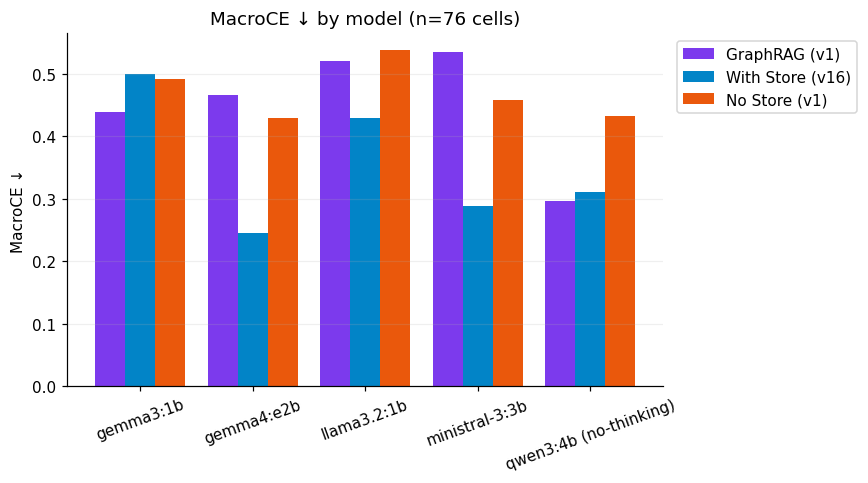

,Model,turns,scored turns,coverage,overall accuracy,scored-turn accuracy,unscored-turn accuracy,mean confidence,mean confidence when wrong
0,gemma3:1b,1600,1290,0.8063,0.2706,0.2992,0.1516,0.6480,0.6129
1,gemma4:e2b,1600,1520,0.9500,0.7544,0.7941,0.0000,0.9836,0.9816
2,llama3.2:1b,1600,1144,0.7150,0.2637,0.3628,0.0154,0.7353,0.7156
3,ministral-3:3b,1600,1537,0.9606,0.7019,0.7306,0.0000,0.7018,0.7863
4,qwen3:4b (no-thinking),1600,666,0.4163,0.3850,0.9159,0.0064,0.9446,0.9536


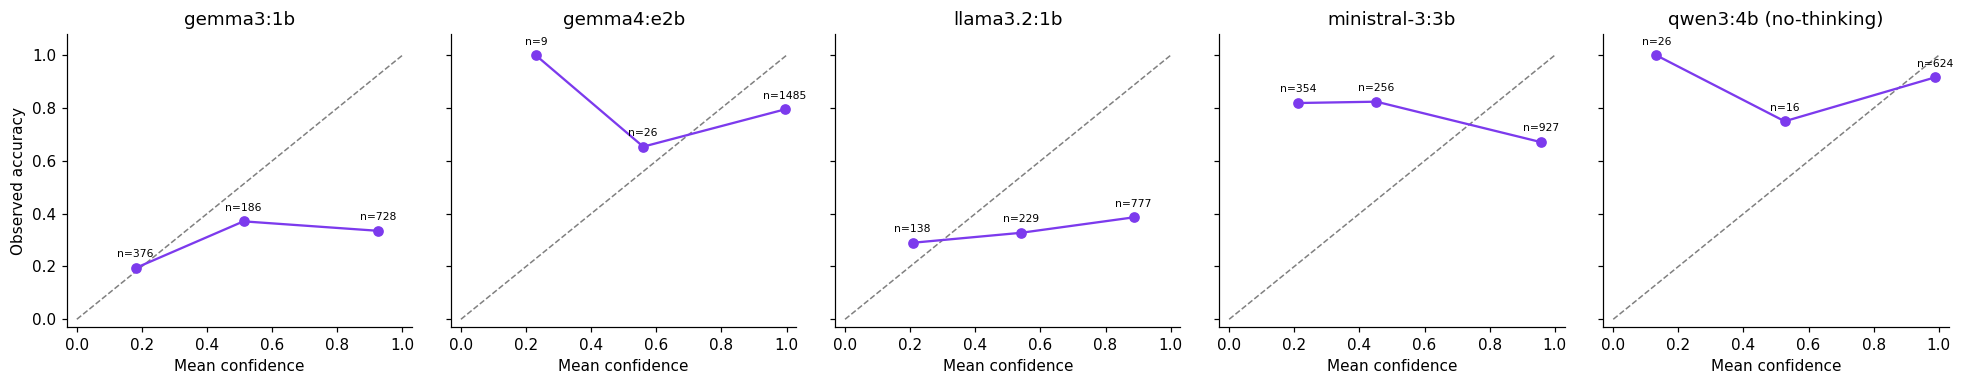

,bin,n,confidence,accuracy,Model
0,0,376,0.1803,0.1941,gemma3:1b
1,1,186,0.5119,0.3710,gemma3:1b
2,2,728,0.9244,0.3352,gemma3:1b
3,0,9,0.2301,1.0000,gemma4:e2b
4,1,26,0.5598,0.6538,gemma4:e2b
5,2,1485,0.9956,0.7953,gemma4:e2b
6,0,138,0.2080,0.2899,llama3.2:1b
7,1,229,0.5402,0.3275,llama3.2:1b
8,2,777,0.8865,0.3861,llama3.2:1b
9,0,354,0.2119,0.8192,ministral-3:3b


In [6]:
for metric in ["Summary_Metric_Brier_Score", "Summary_Metric_Log_Loss", "Summary_Metric_ECE", "Summary_Metric_MacroCE"]:
    table = matched_table(metric)
    display(table.groupby(level="Model").mean())
    bar_chart(table.groupby(level="Model").mean(), f"{metric_names[metric]} by model (n={len(table)} cells)", metric_names[metric])

confidence_rows = []
for model, group in graph.groupby("model"):
    valid = group.p_calibration.notna()
    confidence_rows.append({"Model": model, "turns": len(group), "scored turns": valid.sum(),
        "coverage": valid.mean(), "overall accuracy": group.hit.mean(),
        "scored-turn accuracy": group.loc[valid, "hit"].mean(),
        "unscored-turn accuracy": group.loc[~valid, "hit"].mean(),
        "mean confidence": group.p_calibration.mean(),
        "mean confidence when wrong": group.loc[~group.hit, "p_calibration"].mean()})
display(pd.DataFrame(confidence_rows))

fig, axes = plt.subplots(1, graph.model.nunique(), figsize=(18, 3.6), sharex=True, sharey=True)
reliability_rows = []
for ax, (model, group) in zip(axes, graph.groupby("model")):
    valid = group.dropna(subset=["p_calibration"]).copy()
    valid["bin"] = np.minimum((valid.p_calibration * 3).astype(int), 2)
    bins = valid.groupby("bin").agg(n=("hit", "size"), confidence=("p_calibration", "mean"), accuracy=("hit", "mean"))
    reliability_rows.append(bins.assign(Model=model).reset_index())
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.plot(bins.confidence, bins.accuracy, "o-", color=COLORS[0])
    for row in bins.itertuples():
        ax.annotate(f"n={row.n}", (row.confidence, row.accuracy), xytext=(0, 7), textcoords="offset points", fontsize=7, ha="center")
    ax.set(title=model, xlabel="Mean confidence", xlim=(-0.03, 1.03), ylim=(-0.03, 1.08))
axes[0].set_ylabel("Observed accuracy")
plt.tight_layout()
plt.show()
plt.close(fig)
display(pd.concat(reliability_rows, ignore_index=True))

## 5. Extraction, stability, response length, and variability

All-missing answers can coexist with low answer flip rates because AFR omits missing extractions.
Read EFR, AFR, and determinism together. The extraction-method share is conditional on a method
being recorded; a 100% bracketed-exact share does not imply zero failures.

Raw-score variability is measured across runs, whereas the accuracy SD across domains describes
task heterogeneity. Neither is a standard error of the system difference. Raw-score SDs are only
directly comparable when run lengths agree; the single-agent summary CSV does not record those lengths.

Accuracy SD across domains below uses prompt-averaged accuracy; the remaining metrics retain their labeled prompt versions.

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.3900,0.3162,0.2125
gemma4:e2b,0.0425,0.0481,0.0369
llama3.2:1b,0.1894,0.0606,0.8825
ministral-3:3b,0.0362,0.0025,0.2106
qwen3:4b (no-thinking),0.5938,0.0312,0.0075


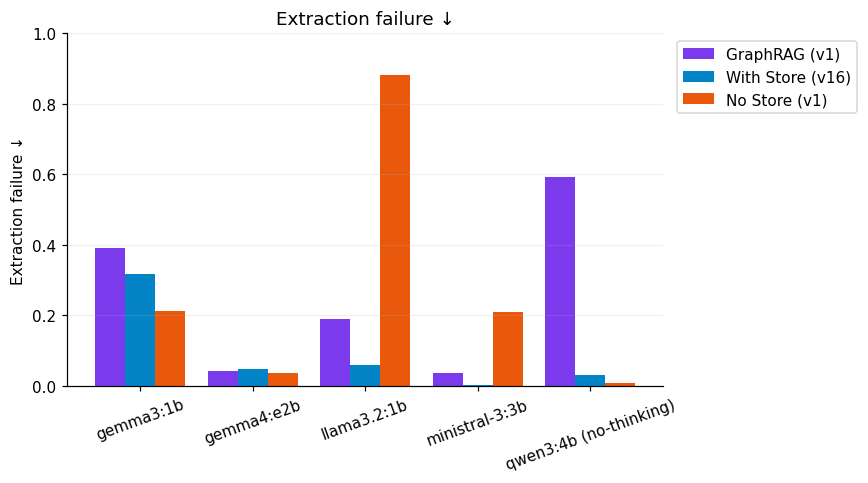

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.1156,0.0185,0.1638
gemma4:e2b,0.0669,0.0159,0.1125
llama3.2:1b,0.1431,0.0631,0.0958
ministral-3:3b,0.0916,0.0206,0.1060
qwen3:4b (no-thinking),0.0000,0.0146,0.0887


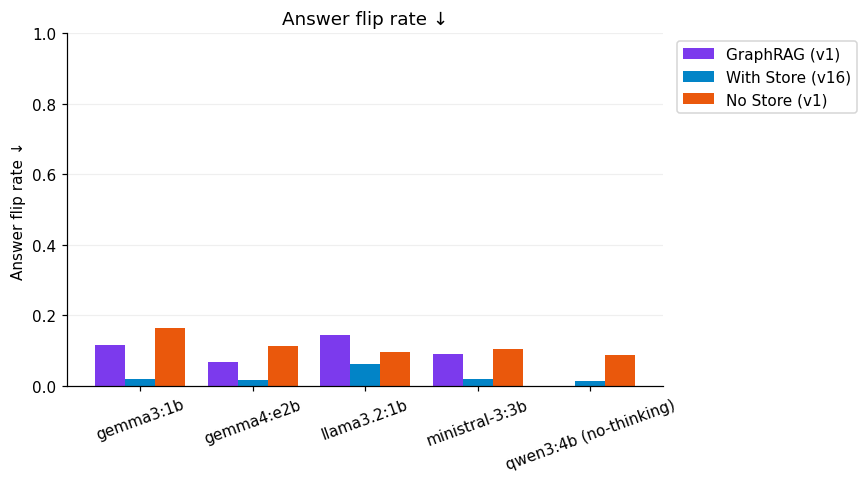

System,GraphRAG (v1),With Store (v16),No Store (v1)
Model,,,
gemma3:1b,0.5687,0.7688,0.4937
gemma4:e2b,0.7625,0.9437,0.6312
llama3.2:1b,0.5312,0.7500,0.1187
ministral-3:3b,0.6875,0.9250,0.5875
qwen3:4b (no-thinking),0.5875,0.9625,0.7312


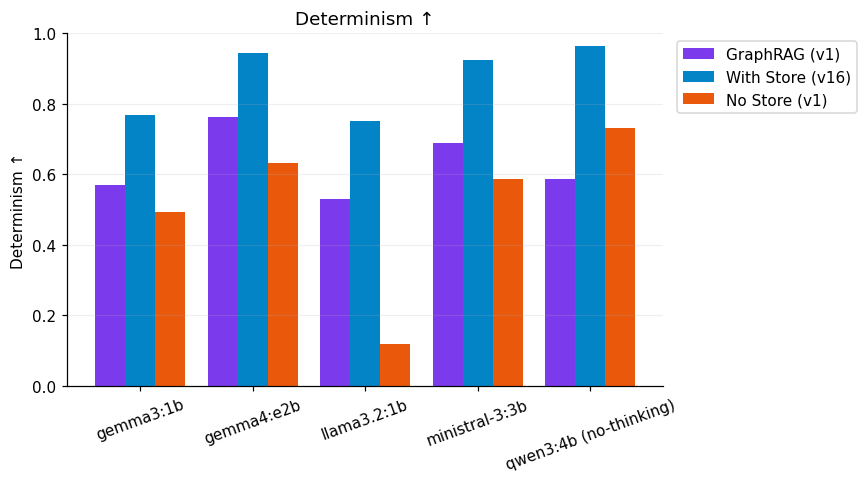

System                                                     GraphRAG (v1)  \
Metric                             Model                                   
Raw-score variance                 gemma3:1b                      0.7701   
                                   gemma4:e2b                     0.3924   
                                   llama3.2:1b                    0.7597   
                                   ministral-3:3b                 0.6174   
                                   qwen3:4b (no-thinking)         0.6833   
Raw-score SD                       gemma3:1b                      0.8569   
                                   gemma4:e2b                     0.5831   
                                   llama3.2:1b                    0.7866   
                                   ministral-3:3b                 0.7257   
                                   qwen3:4b (no-thinking)         0.7865   
Per-turn accuracy variance         gemma3:1b                      0.1176   
                                   gemma4:e2b                     0.1198   
                                   llama3.2:1b                    0.0927   
                                   ministral-3:3b                 0.1160   
                                   qwen3:4b (no-thinking)         0.1520   
Words / correct response           gemma3:1b                     42.2920   
                                   gemma4:e2b                    73.1141   
                                   llama3.2:1b                   59.0613   
                                   ministral-3:3b                50.9944   
                                   qwen3:4b (no-thinking)       300.1214   
Words / incorrect response         gemma3:1b                     40.2928   
                                   gemma4:e2b                   101.6096   
                                   llama3.2:1b                   75.8598   
                                   ministral-3:3b                69.8364   
                                   qwen3:4b (no-thinking)       432.9557   
Bracketed exact / recorded methods gemma3:1b                      1.0000   
                                   gemma4:e2b                     1.0000   
                                   llama3.2:1b                    1.0000   
                                   ministral-3:3b                 1.0000   
                                   qwen3:4b (no-thinking)         1.0000   

System                                                     With Store (v16)  \
Metric                             Model                                      
Raw-score variance                 gemma3:1b                         0.5611   
                                   gemma4:e2b                        0.1146   
                                   llama3.2:1b                       0.3028   
                                   ministral-3:3b                    0.1118   
                                   qwen3:4b (no-thinking)            0.1785   
Raw-score SD                       gemma3:1b                         0.6480   
                                   gemma4:e2b                        0.1863   
                                   llama3.2:1b                       0.4537   
                                   ministral-3:3b                    0.1957   
                                   qwen3:4b (no-thinking)            0.2946   
Per-turn accuracy variance         gemma3:1b                         0.1534   
                                   gemma4:e2b                        0.0859   
                                   llama3.2:1b                       0.1698   
                                   ministral-3:3b                    0.0943   
                                   qwen3:4b (no-thinking)            0.0829   
Words / correct response           gemma3:1b                         5.1250   
                                   gemma4:e2b                       10.1500   
                                   llama3.2:1b                    

**Accuracy SD across matched domains (task heterogeneity):**

,GraphRAG (v1),With Store (mean v15/v16),No Store (mean v1/v2)
Model,,,
gemma3:1b,0.1173,0.2811,0.1254
gemma4:e2b,0.1955,0.1878,0.1896
llama3.2:1b,0.2042,0.2198,0.1439
ministral-3:3b,0.2312,0.1376,0.1853
qwen3:4b (no-thinking),0.2123,0.1319,0.2127


**GraphRAG run-accuracy variability, averaged over domains (all models):**

,mean,std,min,max
model,,,,
gemma3:1b,0.2706,0.0857,0.1500,0.4000
gemma4:e2b,0.7544,0.0583,0.6750,0.8250
llama3.2:1b,0.2637,0.0787,0.1562,0.3875
ministral-3:3b,0.7019,0.0726,0.5813,0.7937
qwen3:4b (no-thinking),0.3850,0.0786,0.2875,0.4938


extraction_method,bracketed_exact,missing
model,,
gemma3:1b,0.6100,0.3900
gemma4:e2b,0.9575,0.0425
llama3.2:1b,0.8106,0.1894
ministral-3:3b,0.9637,0.0362
qwen3:4b (no-thinking),0.4062,0.5938


In [7]:
for metric in ["EFR_Extraction_Failure_Rate", "AFR_Answer_Flip_Rate", "DS_Determinism_Score"]:
    table = matched_table(metric).groupby(level="Model").mean()
    display(table)
    bar_chart(table, metric_names[metric], metric_names[metric], (0, 1))

other_metrics = ["Variance_Raw_Score", "StdDev_Raw_Score", "PTC_Variance_PerTurn_Consistency",
                 "TPCA_Words_Correct", "TPCA_Words_Wrong", "EMD_bracketed_exact"]
display(pd.concat({metric_names[m]: matched_table(m).groupby(level="Model").mean()
                   for m in other_metrics}, names=["Metric", "Model"]))
display(Markdown("**Accuracy SD across matched domains (task heterogeneity):**"))
display(accuracy.groupby(level="Model").std(ddof=1))

run_scores = graph.groupby(["model", "domain", "run"]).hit.agg(correct="sum", accuracy="mean", turns="size")
run_stats = run_scores.groupby(level=["model", "domain"]).accuracy.agg(["mean", "std", "min", "max"])
display(Markdown("**GraphRAG run-accuracy variability, averaged over domains (all models):**"))
display(run_stats.groupby(level="model").mean())
display(pd.crosstab(graph.model, graph.extraction_method.fillna("missing"), normalize="index"))

## 6. Prompt-version sensitivity

These separate prompt results provide the components of the primary aggregated accuracy comparison.
The same GraphRAG v1 results are compared separately with both historical cohorts.
GraphRAG was not rerun under v2. All five columns in each metric below share complete model/domain coverage.
Changes between historical prompt versions may also reflect separate execution dates/settings.

,Matched cells,GraphRAG (v1),With Store (v16),No Store (v1),With Store (v15),No Store (v2)
Accuracy ↑,80.0000,0.4751,0.6579,0.4910,0.7706,0.4381
Brier ↓,76.0000,0.3034,0.2327,0.3294,0.1636,0.3851
ECE ↓,76.0000,0.3248,0.2439,0.3477,0.1660,0.3905
MacroCE ↓,76.0000,0.4479,0.3506,0.4662,0.3588,0.4805
Extraction failure ↓,80.0000,0.2504,0.0917,0.2700,0.0798,0.1349


System,GraphRAG (v1),With Store (v16),No Store (v1),With Store (v15),No Store (v2)
Model,,,,,
gemma3:1b,0.2706,0.4450,0.3206,0.6775,0.4188
gemma4:e2b,0.7544,0.8194,0.7569,0.8600,0.3488
llama3.2:1b,0.2637,0.3063,0.0587,0.4706,0.2906
ministral-3:3b,0.7019,0.8606,0.5775,0.9094,0.6262
qwen3:4b (no-thinking),0.3850,0.8581,0.7412,0.9356,0.5062


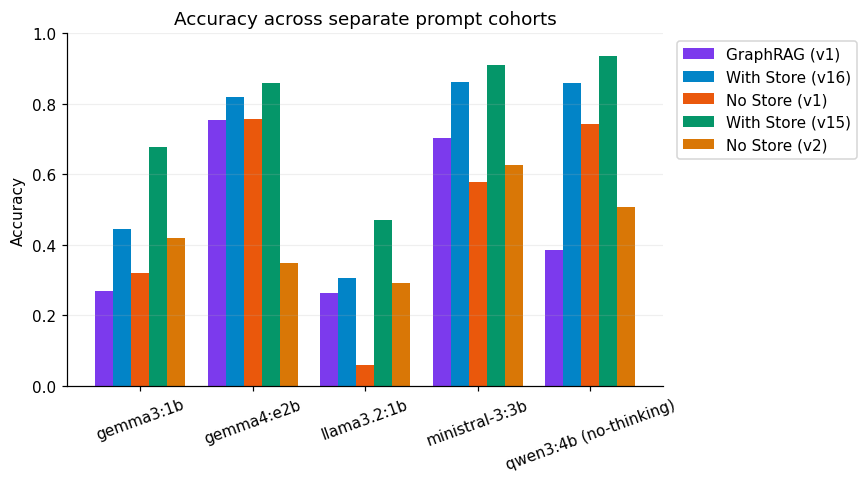

In [8]:
version_tables = {}
for metric in ["Average_Accuracy", "Summary_Metric_Brier_Score", "Summary_Metric_ECE",
               "Summary_Metric_MacroCE", "EFR_Extraction_Failure_Rate"]:
    table = matched_table(metric, ALL_SYSTEMS)
    version_tables[metric_names[metric]] = {"Matched cells": len(table), **table.mean().to_dict()}
display(pd.DataFrame(version_tables).T)
version_accuracy = matched_table("Average_Accuracy", ALL_SYSTEMS).groupby(level="Model").mean()
display(version_accuracy)
bar_chart(version_accuracy, "Accuracy across separate prompt cohorts", "Accuracy", (0, 1))

## 7. Evidence, retrieval fidelity, hard/noise coverage, and supplemental experiments

GraphRAG has retrieved rules/facts but no canonical evidence sets or recorded evidence scores.
These counts are not evidence precision/recall/F1, belief coverage (BCR), or spurious injection (SBIR).
There is no GraphRAG elapsed time. These metrics remain unavailable for GraphRAG; the available single-agent
values below provide context only. Legacy timing is batch elapsed time divided by runs × turns under parallel
execution, not isolated request latency.

**Historical label audit:** some evidence/fidelity/timing rows are labeled `No_Store` in the normalized file.
The evaluator collects evidence/fidelity only for With Store and exports timing once in the store column.
We therefore assign these auxiliary rows to With Store in memory, while showing their original label counts
in Section 2. EMD rows are assigned by their explicit `WithStore`/`NoStore` metric names.
These semantic corrections do not change accuracy, calibration, or stability values. Timing remains a batch
measurement despite its export-column assignment. Source files are never rewritten.

`eval_results_with_store.csv` contains a distinct **v16_one_shot** experiment plus **v15 noise** results.
Some `No_Store` cells contain placeholder zeros from store-only evaluation exports; this supplement is used
only for its `With_Store` column and is not merged into the main v16 cohort. GraphRAG has no hard/noise rows.

In [9]:
context_metrics = sorted(set(single_work.Metric) - set(metric_names))
reference_context = single_work[single_work.Metric.isin(context_metrics)].copy()
reference_context = reference_context.merge(graph_wide[KEYS], on=KEYS, how="inner", validate="many_to_one")
reference_context = reference_context[reference_context.Model.isin(comparison_models)]
display(reference_context.groupby(["Metric", "System"]).Value.agg(mean="mean", available_cells="count").unstack("System"))

domain_presence = pd.DataFrame(index=sorted(set(graph.domain) | set(single.Domain) | set(supplement.Domain)))
domain_presence["GraphRAG"] = domain_presence.index.isin(graph.domain)
domain_presence["Main single-agent"] = domain_presence.index.isin(single.Domain)
domain_presence["Supplement"] = domain_presence.index.isin(supplement.Domain)
display(domain_presence.rename_axis("Domain"))

extra_accuracy = single_work[single_work.Metric.eq("Average_Accuracy") & ~single_work.Domain.isin(graph.domain)]
display(Markdown("**Single-agent-only hard-domain accuracy (no GraphRAG counterpart):**"))
display(extra_accuracy.groupby(["Model", "System"]).Value.mean().unstack())

supp = supplement.rename(columns={"Summary_Metric": "Metric", "With_Store": "Value"}).copy()
supp["Metric"] = supp.Metric.str.replace(r"^EMD_WithStore_", "EMD_", regex=True)
supp["Source_Model"] = supp.Model
supp["Model"] = supp.Model.replace(MODEL_ALIASES)
supp["Scenario"] = supp.Domain.map(scenario_name)
supp_summary = supp[supp.Metric.isin(["Average_Accuracy", "Average_Evidence_F1", "EFR_Extraction_Failure_Rate"])]
display(Markdown("**Supplemental With Store experiments, kept separate:**"))
display(supp_summary.groupby(["Prompt_Ver", "Scenario", "Metric"]).Value.agg(mean="mean", cells="count"))

one_shot = supp[supp.Prompt_Ver.eq("v16_one_shot") & supp.Model.isin(comparison_models)].copy()
one_shot["System"] = "With Store (v16_one_shot)"
supp_combined = pd.concat([combined, one_shot[KEYS + ["Metric", "Value", "System"]]], ignore_index=True)
supp_systems = SYSTEMS + ["With Store (v16_one_shot)"]
supp_rows = []
for metric, label in metric_names.items():
    data = supp_combined[supp_combined.Metric.eq(metric) & supp_combined.Model.isin(comparison_models)]
    table = data.pivot(index=KEYS, columns="System", values="Value").reindex(columns=supp_systems).dropna()
    supp_rows.append({"Metric": label, "Matched cells": len(table), **table.mean().to_dict()})
display(Markdown("**Supplemental one-shot comparison on shared support; no blending with v16:**"))
display(pd.DataFrame(supp_rows).set_index("Metric"))

mean                   \
System                          With Store (v15) With Store (v16)   
Metric                                                              
Average_BCR_BeliefCoverage                0.8125           0.4875   
Average_Evidence_Canonical_Keys           4.8112           2.7075   
Average_Evidence_Cited_Keys               2.2804           1.3499   
Average_Evidence_F1                       0.3565           0.2211   
Average_Evidence_Precision                0.4310           0.2561   
Average_Evidence_Recall                   0.3577           0.2220   
Average_SBIR_SpuriousInjection            0.1920           0.1183   
WCT_WallClock_PerTurn_Seconds            15.9783          17.1703   

                                 available_cells                   
System                          With Store (v15) With Store (v16)  
Metric                                                             
Average_BCR_BeliefCoverage                    80               80  
Average_Evidence_Canonical_Keys               80               80  
Average_Evidence_Cited_Keys                   80               80  
Average_Evidence_F1                           80               80  
Average_Evidence_Precision                    80               80  
Average_Evidence_Recall                       80               80  
Average_SBIR_SpuriousInjection                80               80  
WCT_WallClock_PerTurn_Seconds                 80               80

,GraphRAG,Main single-agent,Supplement
Domain,,,
alien_clinic_absurd,True,True,True
alien_clinic_absurd_temporal,True,True,True
alien_clinic_absurd_temporal_noise,False,False,True
alien_clinic_belief_maintenance,True,True,True
alien_clinic_grounding,True,True,True
alien_clinic_hard,False,True,True
crime_scene_absurd,True,True,True
crime_scene_absurd_temporal,True,True,True
crime_scene_absurd_temporal_noise,False,False,True


**Single-agent-only hard-domain accuracy (no GraphRAG counterpart):**

System,No Store (v1),No Store (v2),With Store (v15),With Store (v16)
Model,,,,
gemma4:e2b,0.3350,0.3325,0.5825,0.4875
ministral-3:3b,0.4950,0.4025,0.5675,0.5275
qwen3:4b (no-thinking),0.4025,0.4075,0.5450,0.5450


**Supplemental With Store experiments, kept separate:**

mean  cells
Prompt_Ver   Scenario              Metric                                   
v15          absurd_temporal_noise Average_Accuracy            0.7535     20
                                   Average_Evidence_F1         0.4109     20
                                   EFR_Extraction_Failure_Rate 0.0920     20
v16_one_shot absurd                Average_Accuracy            0.7860     20
                                   Average_Evidence_F1         0.3336     20
                                   EFR_Extraction_Failure_Rate 0.0850     20
             absurd_temporal       Average_Accuracy            0.7540     20
                                   Average_Evidence_F1         0.1899     20
                                   EFR_Extraction_Failure_Rate 0.0530     20
             belief_maintenance    Average_Accuracy            0.8315     20
                                   Average_Evidence_F1         0.5691     20
                                   EFR_Extraction_Failure_Rate 0.0600     20
             grounding             Average_Accuracy            0.4025     20
                                   Average_Evidence_F1         0.3176     20
                                   EFR_Extraction_Failure_Rate 0.2120     20
             hard                  Average_Accuracy            0.5167     12
                                   Average_Evidence_F1         0.2215     12
                                   EFR_Extraction_Failure_Rate 0.1033     12

**Supplemental one-shot comparison on shared support; no blending with v16:**

,Matched cells,GraphRAG (v1),With Store (v16),No Store (v1),With Store (v16_one_shot)
Metric,,,,,
Accuracy ↑,80,0.4751,0.6579,0.4910,0.6935
Brier ↓,76,0.3034,0.2327,0.3294,0.2063
Log loss ↓,76,1.7130,1.5586,2.4720,1.2995
ECE ↓,76,0.3248,0.2439,0.3477,0.2157
MacroCE ↓,76,0.4479,0.3506,0.4662,0.3729
Extraction failure ↓,80,0.2504,0.0917,0.2700,0.1025
Answer flip rate ↓,80,0.0834,0.0265,0.1134,0.0336
Determinism ↑,80,0.6275,0.8700,0.5125,0.8300
Raw-score variance,80,0.6446,0.2538,0.7253,0.3139


## 8. Qwen no-thinking results

Both Qwen results are included as `qwen3:4b (no-thinking)` in the comparison charts and summaries.
The tables below show its aggregated accuracy and other metrics, using the same prompt weighting
and matched-domain policy as the main comparison.


In [10]:
qwen_ids = [QWEN_LABEL]
qwen_accuracy_rows = combined[combined.Model.isin(qwen_ids) & combined.Metric.eq("Average_Accuracy")]
qwen_variants = qwen_accuracy_rows.pivot(index=["Domain", "Temp", "Runs"], columns="System", values="Value")
qwen_aggregated = aggregate_accuracy(qwen_variants)
display(Markdown("**qwen3:4b (no-thinking) — aggregated accuracy:**"))
display(qwen_aggregated.mean().rename("Accuracy").to_frame().assign(matched_domains=len(qwen_aggregated)))
qwen_rows = []
for metric, label in metric_names.items():
    data = combined[combined.Model.isin(qwen_ids) & combined.Metric.eq(metric) & combined.System.isin(SYSTEMS)]
    table = data.pivot(index=["Domain", "Temp", "Runs"], columns="System", values="Value").reindex(columns=SYSTEMS).dropna()
    qwen_rows.append({"Metric": label, "Matched domains": len(table), **table.mean().to_dict()})
display(pd.DataFrame(qwen_rows).set_index("Metric"))


**qwen3:4b (no-thinking) — aggregated accuracy:**

,Accuracy,matched_domains
GraphRAG (v1),0.3850,16
With Store (mean v15/v16),0.8969,16
No Store (mean v1/v2),0.6237,16


,Matched domains,GraphRAG (v1),With Store (v16),No Store (v1)
Metric,,,,
Accuracy ↑,16,0.3850,0.8581,0.7412
Brier ↓,16,0.1297,0.1349,0.2398
Log loss ↓,16,1.4158,1.5916,3.0356
ECE ↓,16,0.1458,0.1350,0.2370
MacroCE ↓,16,0.2969,0.3111,0.4325
Extraction failure ↓,16,0.5938,0.0312,0.0075
Answer flip rate ↓,16,0.0000,0.0147,0.0888
Determinism ↑,16,0.5875,0.9625,0.7312
Raw-score variance,16,0.6833,0.1785,0.6222


## 9. GraphRAG-specific diagnostics

Retrieval size, response length, turn position, and answer extraction help explain failure patterns.
Context characters are not token counts, cost, or latency; associations with accuracy are not causal.
Retrieved rule/fact counts describe the supplied context, not its correctness or completeness.

,accuracy,extraction_failure,mean_rules,mean_facts,mean_context_chars,p95_context_chars,mean_response_words
model,,,,,,,
gemma3:1b,0.2706,0.3900,4.5250,5.4062,1200.1188,3588.0000,40.5862
gemma4:e2b,0.7544,0.0425,4.5250,5.4062,1200.1188,3588.0000,81.9150
llama3.2:1b,0.2637,0.1894,4.5250,5.4062,1200.1188,3588.0000,70.9025
ministral-3:3b,0.7019,0.0362,4.5250,5.4062,1200.1188,3588.0000,57.9344
qwen3:4b (no-thinking),0.3850,0.5938,4.5250,5.4062,1200.1188,3588.0000,374.7975


retrieved_rule_count  retrieved_fact_count  \
model                  hit                                                 
gemma3:1b              False                4.6924                5.6135   
                       True                 4.0739                4.8476   
gemma4:e2b             False                5.9796                5.8372   
                       True                 4.0514                5.2659   
llama3.2:1b            False                4.9329                5.9372   
                       True                 3.3863                3.9242   
ministral-3:3b         False                5.5681                6.3229   
                       True                 4.0819                5.0169   
qwen3:4b (no-thinking) False                5.6413                6.5295   
                       True                 2.7419                3.6120   

                              context_chars  response_words  
model                  hit                                   
gemma3:1b              False      1244.9991         40.6427  
                       True       1079.1594         40.4342  
gemma4:e2b             False      1832.1170        109.0560  
                       True        994.3397         73.0779  
llama3.2:1b            False      1318.7334         76.5951  
                       True        869.0095         55.0118  
ministral-3:3b         False      1649.9832         79.3312  
                       True       1009.0365         48.8459  
qwen3:4b (no-thinking) False      1516.5610        427.8699  
                       True        694.6331        290.0195

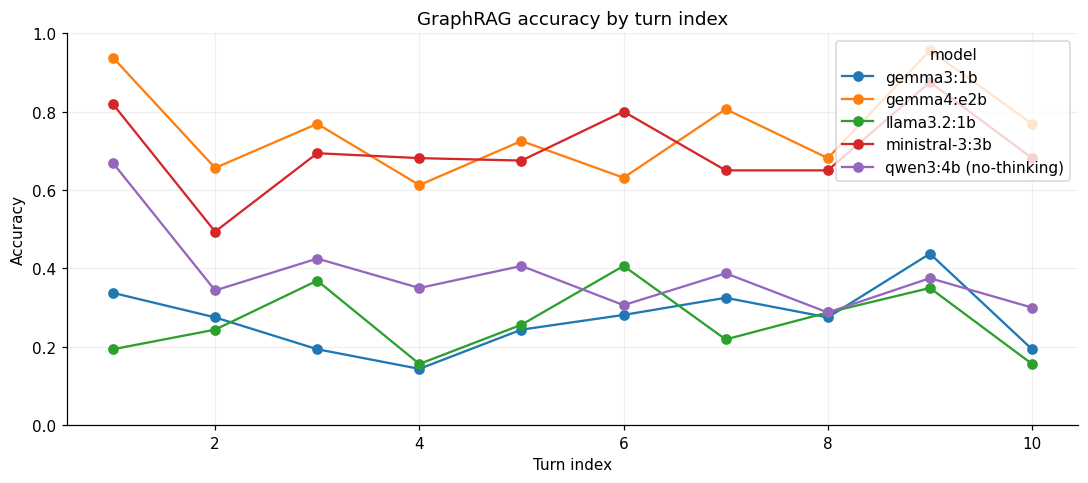

turns  accuracy  confidence_coverage
model                  extracted                                      
gemma3:1b              False        624    0.0000               0.6587
                       True         976    0.4436               0.9006
gemma4:e2b             False         68    0.0000               0.0294
                       True        1532    0.7879               0.9909
llama3.2:1b            False        303    0.0000               0.1551
                       True        1297    0.3254               0.8458
ministral-3:3b         False         58    0.0000               0.3793
                       True        1542    0.7283               0.9825
qwen3:4b (no-thinking) False        950    0.0000               0.0232
                       True         650    0.9477               0.9908

In [11]:
diagnostics = graph.groupby("model").agg(
    accuracy=("hit", "mean"), extraction_failure=("answer", lambda s: s.isna().mean()),
    mean_rules=("retrieved_rule_count", "mean"), mean_facts=("retrieved_fact_count", "mean"),
    mean_context_chars=("context_chars", "mean"), p95_context_chars=("context_chars", lambda s: s.quantile(.95)),
    mean_response_words=("response_words", "mean"),
)
display(diagnostics)
display(graph.groupby(["model", "hit"])[["retrieved_rule_count", "retrieved_fact_count", "context_chars", "response_words"]].mean())

turn_accuracy = graph.groupby(["turn", "model"]).hit.mean().unstack()
ax = turn_accuracy.plot(marker="o", figsize=(10, 4.5), ylim=(0, 1), title="GraphRAG accuracy by turn index")
ax.set(ylabel="Accuracy", xlabel="Turn index")
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()
plt.close(ax.figure)
display(graph.assign(extracted=graph.answer.notna()).groupby(["model", "extracted"]).agg(
    turns=("hit", "size"), accuracy=("hit", "mean"), confidence_coverage=("p_calibration", lambda s: s.notna().mean())))

## 10. Reproducibility checks and data-derived findings

The checks below exercise aggregation on a small example and verify that primary comparisons use identical
support and consistent model labels. Findings are generated from the current files rather than copied from the
reference notebook's narrative. Stored outputs reflect the file hashes shown at the start.

In [12]:
toy = pd.DataFrame({
    "run": [1, 1, 2, 2], "turn": [1, 2, 1, 2], "hit": [True, False, False, False],
    "answer": ["A", None, "B", None], "p_calibration": [1.0, np.nan, 0.5, np.nan],
    "response_words": [2, 4, 6, 8], "extraction_method": ["bracketed_exact", None, "bracketed_exact", None],
})
toy_result = summarize_graph(toy)
assert np.isclose(toy_result["Average_Accuracy"], .25)
assert np.isclose(toy_result["Variance_Raw_Score"], .5)
assert np.isclose(toy_result["AFR_Answer_Flip_Rate"], .5)
assert np.isclose(toy_result["DS_Determinism_Score"], 0)
assert np.isclose(toy_result["EFR_Extraction_Failure_Rate"], .5)
assert np.isclose(toy_result["Summary_Metric_Brier_Score"], .125)
assert np.isclose(toy_result["Summary_Metric_ECE"], .25)
assert np.isclose(toy_result["Summary_Metric_MacroCE"], .25)
assert np.isclose(toy_result["PTC_Variance_PerTurn_Consistency"], .125)
assert np.isnan(summarize_graph(toy.assign(p_calibration=np.nan))["Summary_Metric_Brier_Score"])
assert np.isnan(summarize_graph(toy.assign(answer=None))["AFR_Answer_Flip_Rate"])
assert set(accuracy.index.get_level_values("Model")) == set(comparison_models)
assert QWEN_LABEL in comparison_models
# Confirm label normalization preserves Qwen scores and includes it in every available metric chart.
qwen_source = single[single.Model.eq("hoangquan456/qwen3-nothink:4b") &
                     single.Summary_Metric.eq("Average_Accuracy") & single.Domain.isin(graph.domain)]
assert np.isclose(accuracy.xs(QWEN_LABEL)[ACCURACY_SYSTEMS[1]].mean(),
                  qwen_source.loc[qwen_source.Condition.eq("With_Store"), "Value"].mean())
for metric in metric_names:
    assert QWEN_LABEL in matched_table(metric).index.get_level_values("Model"), metric
assert QWEN_LABEL in version_accuracy.index
assert accuracy.notna().all().all()
assert np.isclose(graph_wide.Average_Accuracy.mean(), graph.hit.mean())
# Verify equal variant weights and reject incomplete variant pairs.
variant_toy = pd.DataFrame({"GraphRAG (v1)": [.4, .4], "With Store (v15)": [.2, .2],
    "With Store (v16)": [.8, np.nan], "No Store (v1)": [.1, .1], "No Store (v2)": [.5, .5]})
aggregated_toy = aggregate_accuracy(variant_toy)
assert len(aggregated_toy) == 1
assert np.allclose(aggregated_toy.iloc[0], [.4, .5, .3])
assert accuracy.index.equals(accuracy_variants.index)
assert np.allclose(accuracy[ACCURACY_SYSTEMS[1]],
                   (accuracy_variants["With Store (v15)"] + accuracy_variants["With Store (v16)"]) / 2)
assert np.allclose(accuracy[ACCURACY_SYSTEMS[0]], accuracy_variants["GraphRAG (v1)"])
print("Aggregation, prompt weighting, missingness, and matched-support checks passed.")

means = accuracy.mean()
findings = [f"Primary support: **{len(accuracy)} model–domain cells across {len(comparison_models)} models**."]
for system in ACCURACY_SYSTEMS:
    findings.append(f"{system}: **{means[system]:.2%}** macro accuracy on that shared support (prompt averaging as labeled).")
for baseline in ACCURACY_SYSTEMS[1:]:
    findings.append(f"GraphRAG minus {baseline}: **{100 * (means[ACCURACY_SYSTEMS[0]] - means[baseline]):+.2f} pp**.")
findings.append(f"Across all GraphRAG models, **{graph.answer.isna().mean():.2%}** of turns lack an extracted answer; "
                f"**{graph.p_calibration.notna().mean():.2%}** have usable calibration confidence.")
findings.append("With Store accuracy averages v15/v16; No Store accuracy averages v1/v2. Calibration and stability retain their labeled prompt versions and metric-specific support counts. "
                "Evidence/fidelity/timing are unavailable for GraphRAG; "
                "unverified historical question pairing, and supplied-target retrieval limit attribution.")
display(Markdown("\n\n".join("- " + item for item in findings)))

Aggregation, prompt weighting, missingness, and matched-support checks passed.


- Primary support: **80 model–domain cells across 5 models**.

- GraphRAG (v1): **47.51%** macro accuracy on that shared support (prompt averaging as labeled).

- With Store (mean v15/v16): **71.42%** macro accuracy on that shared support (prompt averaging as labeled).

- No Store (mean v1/v2): **46.46%** macro accuracy on that shared support (prompt averaging as labeled).

- GraphRAG minus With Store (mean v15/v16): **-23.91 pp**.

- GraphRAG minus No Store (mean v1/v2): **+1.06 pp**.

- Across all GraphRAG models, **25.04%** of turns lack an extracted answer; **76.96%** have usable calibration confidence.

- With Store accuracy averages v15/v16; No Store accuracy averages v1/v2. Calibration and stability retain their labeled prompt versions and metric-specific support counts. Evidence/fidelity/timing are unavailable for GraphRAG; unverified historical question pairing, and supplied-target retrieval limit attribution.